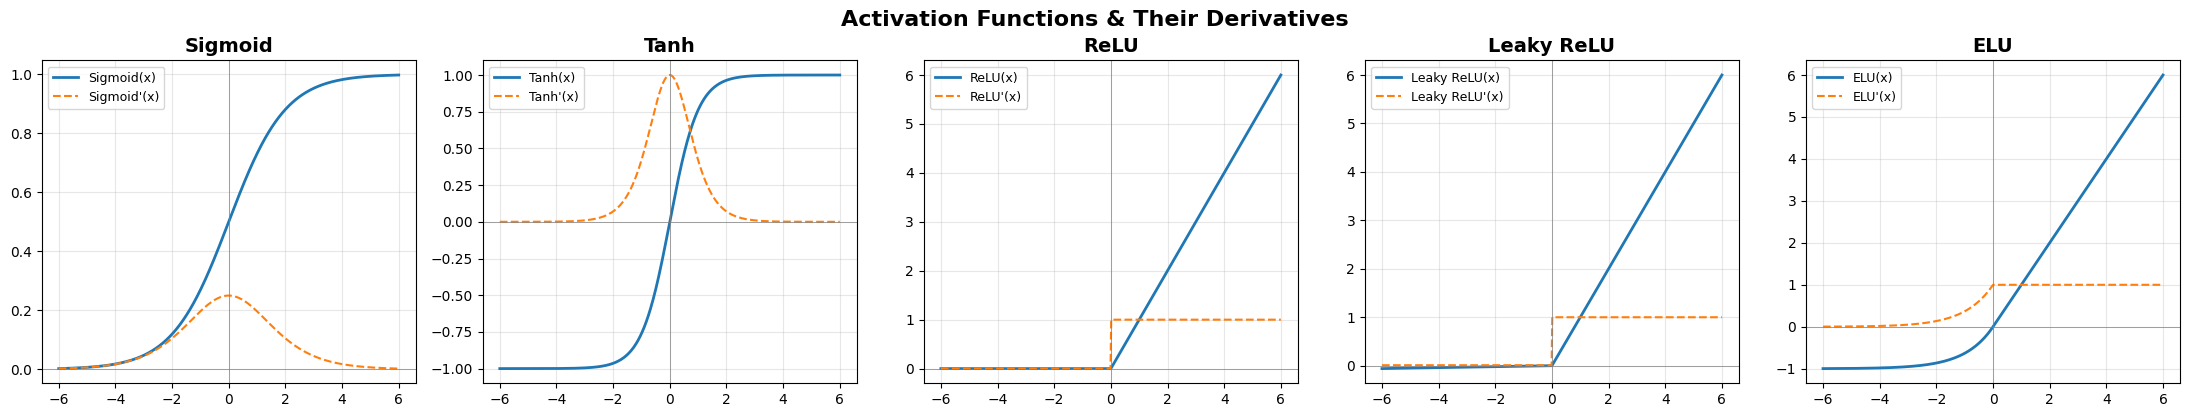

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 500)

# 所有激活函数
def sigmoid(x):    return 1 / (1 + np.exp(-x))
def tanh(x):       return np.tanh(x)
def relu(x):       return np.maximum(0, x)
def leaky_relu(x): return np.where(x > 0, x, 0.01 * x)
def elu(x, a=1.0): return np.where(x > 0, x, a * (np.exp(x) - 1))

# 导数
def sigmoid_d(x):  s = sigmoid(x); return s * (1 - s)
def tanh_d(x):     return 1 - np.tanh(x) ** 2
def relu_d(x):     return np.where(x > 0, 1.0, 0.0)
def leaky_relu_d(x): return np.where(x > 0, 1.0, 0.01)
def elu_d(x, a=1.0): return np.where(x > 0, 1.0, a * np.exp(x))

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
funcs = [
    ("Sigmoid", sigmoid, sigmoid_d),
    ("Tanh", tanh, tanh_d),
    ("ReLU", relu, relu_d),
    ("Leaky ReLU", leaky_relu, leaky_relu_d),
    ("ELU", elu, elu_d),
]

for ax, (name, f, df) in zip(axes, funcs):
    ax.plot(x, f(x), linewidth=2, label=f"{name}(x)")
    ax.plot(x, df(x), linewidth=1.5, linestyle="--", label=f"{name}'(x)")
    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.suptitle("Activation Functions & Their Derivatives", y=1.03, fontsize=16, fontweight="bold")
plt.show()

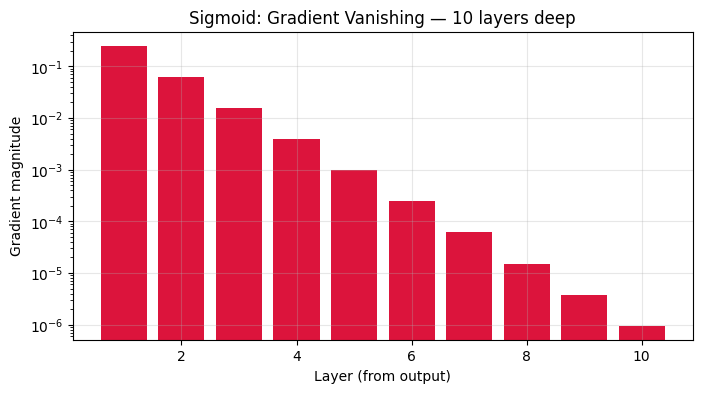

经过 10 层，梯度衰减到 9.54e-07
结论：深层网络几乎无法训练——底层参数几乎不更新。


In [10]:
## 1. Sigmoid: σ(x) = 1 / (1 + e^(-x))

"""
**输出范围**: (0, 1)  |  **导数最大值**: 0.25

### 为什么需要它？
最早的神经元模型（感知机）用的是阶跃函数 `0/1`，不可微，没法反向传播。
Sigmoid 是阶跃函数的**平滑近似**——处处可导，输出可以解释为概率。
"""

### 致命问题：梯度消失

# 直观展示：梯度在反向传播中逐层衰减
layer_gradients = []
g = 1.0  # 从输出层开始
for layer in range(10):
    g *= 0.25  # sigmoid 导数最大 0.25
    layer_gradients.append(g)

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), layer_gradients, color="crimson")
plt.xlabel("Layer (from output)")
plt.ylabel("Gradient magnitude")
plt.title("Sigmoid: Gradient Vanishing — 10 layers deep")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.show()

print(f"经过 10 层，梯度衰减到 {layer_gradients[-1]:.2e}")
print("结论：深层网络几乎无法训练——底层参数几乎不更新。")

Sigmoid 的三大罪状：
1. 梯度消失：导数最大 0.25，多层相乘后趋近于 0
2. 输出非零中心：σ(x) ∈ (0,1)，导致梯度更新呈锯齿形(zig-zag)，收敛慢
3. 指数运算昂贵：exp() 比简单比较慢得多


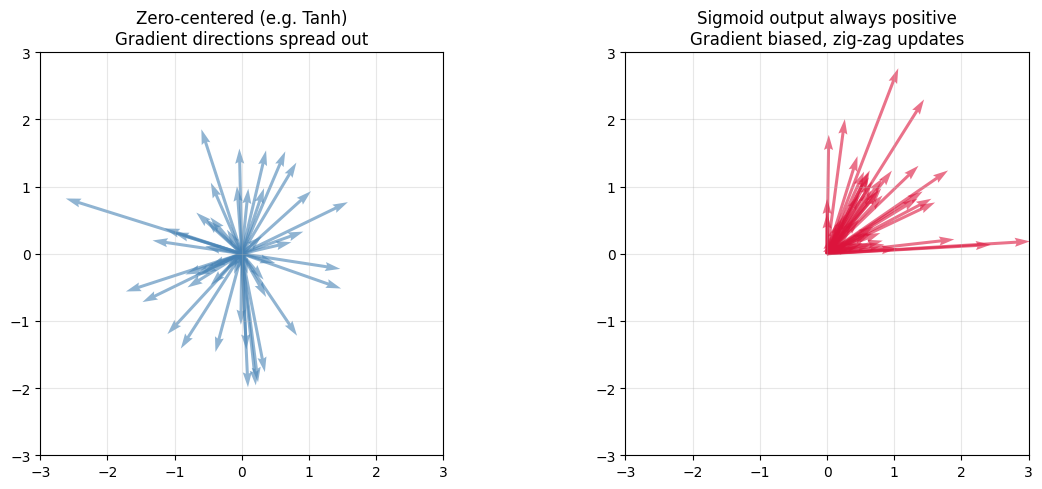

In [11]:
### Sigmoid 的其他问题

print("Sigmoid 的三大罪状：")
print("1. 梯度消失：导数最大 0.25，多层相乘后趋近于 0")
print("2. 输出非零中心：σ(x) ∈ (0,1)，导致梯度更新呈锯齿形(zig-zag)，收敛慢")
print("3. 指数运算昂贵：exp() 比简单比较慢得多")

# 问题2的直观演示：非零中心导致梯度方向问题
np.random.seed(42)
w_grads_zero_center = np.random.randn(1000, 2)      # 模拟零中心输出
w_grads_sigmoid = np.abs(np.random.randn(1000, 2))   # 模拟 sigmoid 的正输出

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].quiver(np.zeros(50), np.zeros(50),
               w_grads_zero_center[:50, 0], w_grads_zero_center[:50, 1],
               angles='xy', scale_units='xy', scale=1, alpha=0.6, color="steelblue")
axes[0].set_title("Zero-centered (e.g. Tanh)\nGradient directions spread out", fontsize=12)
axes[0].set_xlim(-3, 3); axes[0].set_ylim(-3, 3); axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

axes[1].quiver(np.zeros(50), np.zeros(50),
               w_grads_sigmoid[:50, 0], w_grads_sigmoid[:50, 1],
               angles='xy', scale_units='xy', scale=1, alpha=0.6, color="crimson")
axes[1].set_title("Sigmoid output always positive\nGradient biased, zig-zag updates", fontsize=12)
axes[1].set_xlim(-3, 3); axes[1].set_ylim(-3, 3); axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

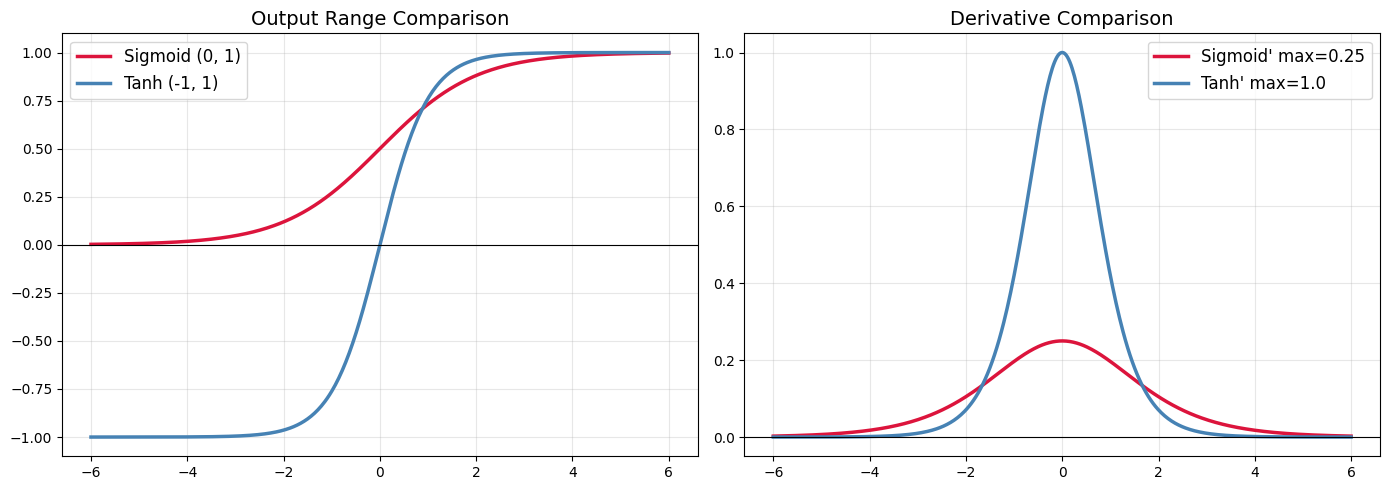

Tanh 的改进：
  [OK] 输出零中心 → 梯度更新方向更一致，收敛更快
  [OK] 导数最大值 1.0（vs Sigmoid 的 0.25）→ 梯度消失减轻 4 倍

Tanh 的遗留问题：
  [X] 两端仍然饱和（|x| 大时导数趋近 0）→ 梯度消失没有根治


In [12]:
## 2. Tanh: tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))

"""
**输出范围**: (-1, 1)  |  **导数最大值**: 1.0

### 设计动机：解决 Sigmoid 的非零中心问题

Tanh 就是缩放平移后的 Sigmoid:  `tanh(x) = 2σ(2x) - 1`
"""

# 对比 Sigmoid 和 Tanh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：函数对比
axes[0].plot(x, sigmoid(x), linewidth=2.5, label="Sigmoid (0, 1)", color="crimson")
axes[0].plot(x, tanh(x), linewidth=2.5, label="Tanh (-1, 1)", color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Output Range Comparison", fontsize=14)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# 右图：导数对比
axes[1].plot(x, sigmoid_d(x), linewidth=2.5, label="Sigmoid' max=0.25", color="crimson")
axes[1].plot(x, tanh_d(x), linewidth=2.5, label="Tanh' max=1.0", color="steelblue")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Derivative Comparison", fontsize=14)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Tanh 的改进：")
print("  [OK] 输出零中心 → 梯度更新方向更一致，收敛更快")
print("  [OK] 导数最大值 1.0（vs Sigmoid 的 0.25）→ 梯度消失减轻 4 倍")
print()
print("Tanh 的遗留问题：")
print("  [X] 两端仍然饱和（|x| 大时导数趋近 0）→ 梯度消失没有根治")

梯度在 10 层网络中的衰减（假设每层输入在饱和区）：

Sigmoid: 0.25^10 = 9.54e-07
Tanh:    0.5^10  = 9.77e-04
ReLU:    1.0^10  = 1.00e+00  <-- no decay!

计算速度（1,000,000 个元素 x 100 次）：
  Sigmoid: 0.616s
  ReLU:    0.060s
  ReLU is 10.3x faster


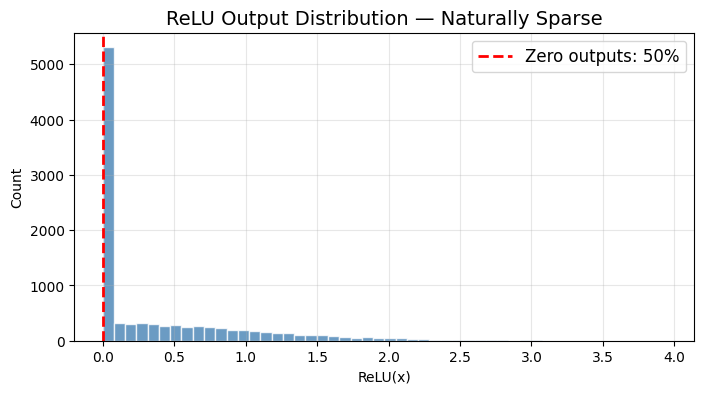

In [13]:
## 3. ReLU: f(x) = max(0, x)

"""
**输出范围**: [0, +∞)  |  **导数**: 0 或 1

### 设计动机：彻底消灭梯度消失
"""

# 对比所有函数的梯度衰减
print("梯度在 10 层网络中的衰减（假设每层输入在饱和区）：\n")

# Sigmoid: 导数最大 0.25
print(f"Sigmoid: 0.25^10 = {0.25**10:.2e}")
# Tanh: 导数最大 1.0，但饱和区接近 0，取典型值 0.5
print(f"Tanh:    0.5^10  = {0.5**10:.2e}")
# ReLU: 导数恒为 1（正区间）
print(f"ReLU:    1.0^10  = {1.0**10:.2e}  <-- no decay!")

# ReLU 的计算极简
import time

N = 1_000_000
data = np.random.randn(N)

t0 = time.perf_counter()
for _ in range(100): _ = 1 / (1 + np.exp(-data))
t_sigmoid = time.perf_counter() - t0

t0 = time.perf_counter()
for _ in range(100): _ = np.maximum(0, data)
t_relu = time.perf_counter() - t0

print(f"\n计算速度（{N:,} 个元素 x 100 次）：")
print(f"  Sigmoid: {t_sigmoid:.3f}s")
print(f"  ReLU:    {t_relu:.3f}s")
print(f"  ReLU is {t_sigmoid/t_relu:.1f}x faster")

# ReLU 的稀疏性
x_sample = np.random.randn(10000)
relu_output = relu(x_sample)
sparsity = np.mean(relu_output == 0) * 100

plt.figure(figsize=(8, 4))
plt.hist(relu_output, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(0, color="red", linewidth=2, linestyle="--", label=f"Zero outputs: {sparsity:.0f}%")
plt.title("ReLU Output Distribution — Naturally Sparse", fontsize=14)
plt.xlabel("ReLU(x)")
plt.ylabel("Count")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

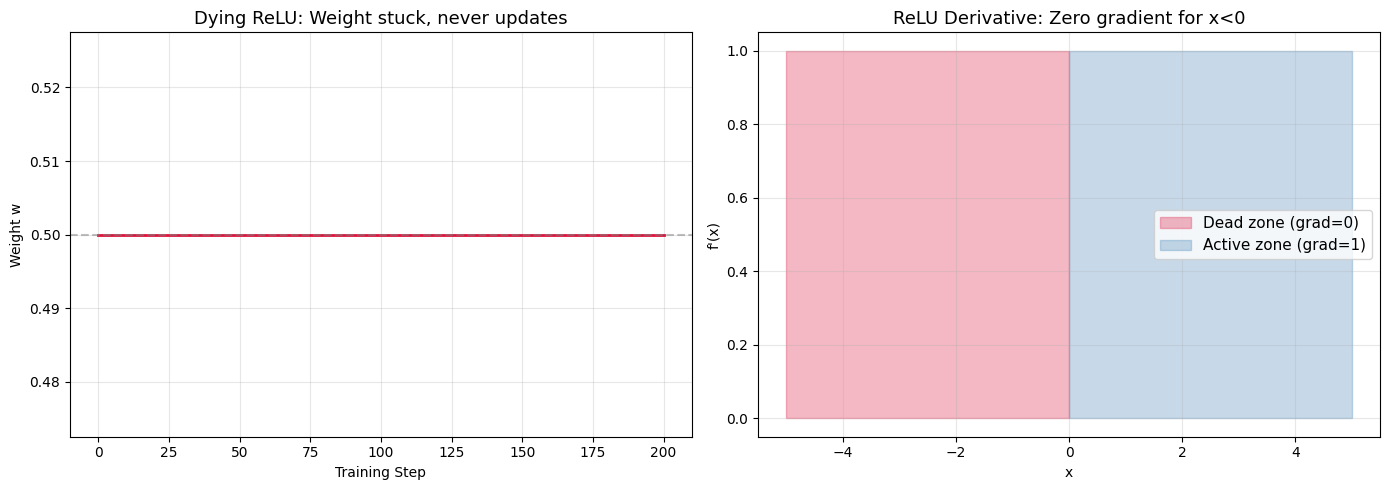

Dying ReLU 机制：
  1. 某个神经元的输入 w*x+b 持续为负
  2. 输出恒为 0，梯度恒为 0
  3. 权重永远不更新 → 该神经元永久死亡
  4. 大学习率会让更多神经元死亡


In [14]:
### ReLU 的致命问题：Dying ReLU（神经元死亡）


# 模拟 Dying ReLU：一旦输入变负，梯度为 0，参数永远不更新
np.random.seed(42)
w = 0.5
b = -3.0  # 偏置为负，使大部分输入落在负区间
lr = 0.01

trajectory_w = [w]
for step in range(200):
    x_in = np.random.randn() * 2
    z = w * x_in + b
    if z > 0:
        grad = x_in
        w -= lr * grad
    # z <= 0: grad = 0, w 不更新
    trajectory_w.append(w)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：参数轨迹
axes[0].plot(trajectory_w, linewidth=2, color="crimson")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Weight w")
axes[0].set_title("Dying ReLU: Weight stuck, never updates", fontsize=13)
axes[0].axhline(w, color="gray", linestyle="--", alpha=0.5)
axes[0].grid(True, alpha=0.3)

# 右图：ReLU 导数——x<0 时梯度彻底为 0
x_neg = np.linspace(-5, 0, 100)
x_pos = np.linspace(0, 5, 100)
axes[1].fill_between(x_neg, 0, 1, alpha=0.3, color="crimson", label="Dead zone (grad=0)")
axes[1].fill_between(x_pos, 0, 1, alpha=0.3, color="steelblue", label="Active zone (grad=1)")
axes[1].set_title("ReLU Derivative: Zero gradient for x<0", fontsize=13)
axes[1].set_xlabel("x")
axes[1].set_ylabel("f'(x)")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Dying ReLU 机制：")
print("  1. 某个神经元的输入 w*x+b 持续为负")
print("  2. 输出恒为 0，梯度恒为 0")
print("  3. 权重永远不更新 → 该神经元永久死亡")
print("  4. 大学习率会让更多神经元死亡")

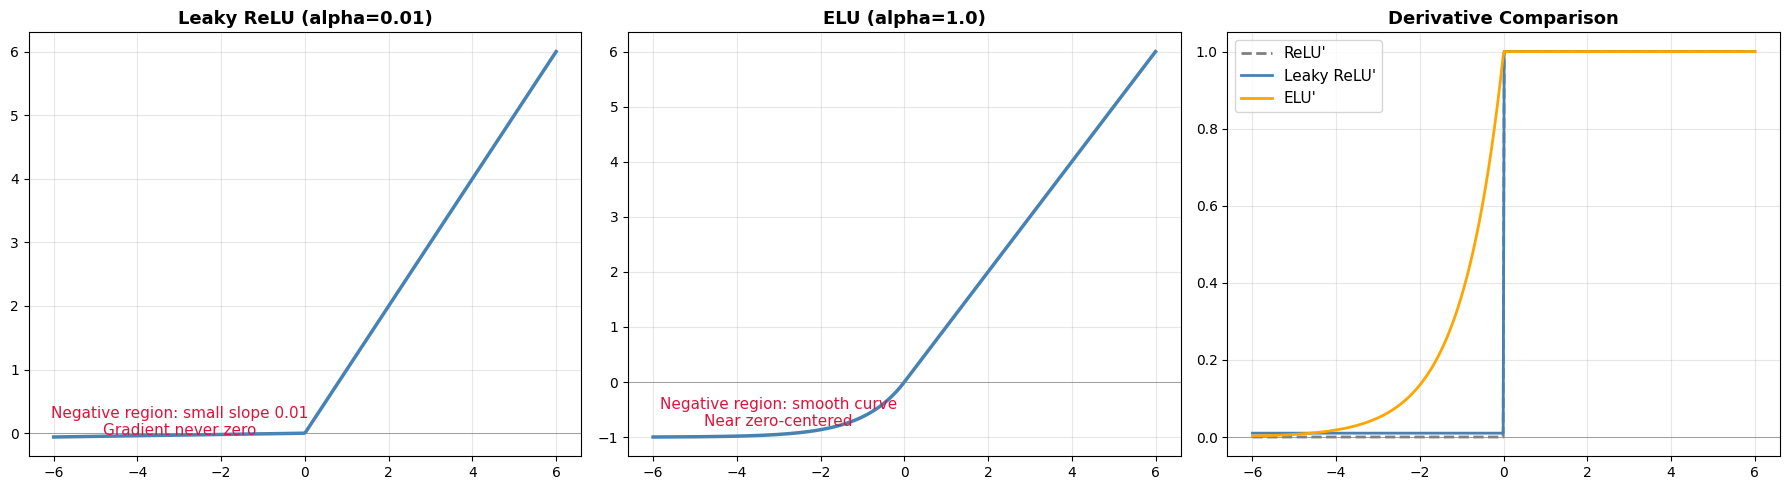

修复思路：

Leaky ReLU: 最简单的修补
  负区间给一个很小的斜率 (0.01)，保证梯度不为零
  神经元不会死亡，但负区间的斜率是超参数，需要调

ELU: 更优雅的修补
  负区间用指数曲线，输出接近零中心
  比 Leaky ReLU 更平滑，收敛通常更快
  代价：需要计算 exp()，比 Leaky ReLU 慢


In [15]:
## 4. Leaky ReLU & ELU：修复 Dying ReLU

# 三种修复方案对比
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Leaky ReLU
axes[0].plot(x, leaky_relu(x), linewidth=2.5, color="steelblue")
axes[0].set_title("Leaky ReLU (alpha=0.01)", fontsize=13, fontweight="bold")
axes[0].annotate("Negative region: small slope 0.01\nGradient never zero", xy=(-3, -0.03), fontsize=11,
                 color="crimson", ha="center")
axes[0].grid(True, alpha=0.3); axes[0].axhline(0, color="gray", linewidth=0.5)

# ELU
axes[1].plot(x, elu(x), linewidth=2.5, color="steelblue")
axes[1].set_title("ELU (alpha=1.0)", fontsize=13, fontweight="bold")
axes[1].annotate("Negative region: smooth curve\nNear zero-centered", xy=(-3, -0.8), fontsize=11,
                 color="crimson", ha="center")
axes[1].grid(True, alpha=0.3); axes[1].axhline(0, color="gray", linewidth=0.5)

# 导数对比
axes[2].plot(x, relu_d(x), linewidth=2, label="ReLU'", color="gray", linestyle="--")
axes[2].plot(x, leaky_relu_d(x), linewidth=2, label="Leaky ReLU'", color="steelblue")
axes[2].plot(x, elu_d(x), linewidth=2, label="ELU'", color="orange")
axes[2].set_title("Derivative Comparison", fontsize=13, fontweight="bold")
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3); axes[2].axhline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

print("修复思路：")
print()
print("Leaky ReLU: 最简单的修补")
print("  负区间给一个很小的斜率 (0.01)，保证梯度不为零")
print("  神经元不会死亡，但负区间的斜率是超参数，需要调")
print()
print("ELU: 更优雅的修补")
print("  负区间用指数曲线，输出接近零中心")
print("  比 Leaky ReLU 更平滑，收敛通常更快")
print("  代价：需要计算 exp()，比 Leaky ReLU 慢")

In [16]:
## Summary: What Each Iteration Solved

print("=" * 70)
print(f"{'Activation':<15} {'Solved':<25} {'Introduced':<25}")
print("=" * 70)
print(f"{'Sigmoid':<15} {'Step fn not differentiable':<25} {'Vanishing grad + not zero-centered':<25}")
print(f"{'Tanh':<15} {'Zero-centered output':<25} {'Saturates at both ends':<25}")
print(f"{'ReLU':<15} {'Vanishing grad (positive)':<25} {'Dying ReLU':<25}")
print(f"{'Leaky ReLU':<15} {'Dying ReLU':<25} {'Negative slope is hyperparam':<25}")
print(f"{'ELU':<15} {'Dying ReLU + zero-centered':<25} {'Needs exp(), slightly slower':<25}")
print("=" * 70)

print("""
Evolution (one-liner):

  Sigmoid  Smooth approx of step fn, but gradient vanishes
    |
    v  Solve non-zero-centered
  Tanh     Zero-centered output, but saturates at extremes
    |
    v  Eliminate vanishing gradient
  ReLU     Grad=1 for x>0, but grad=0 for x<0
    |
    v  Fix Dying ReLU
  Leaky ReLU / ELU   Gradient in negative region too

Practice tips:
  - Default to ReLU, works for most cases
  - If many dead neurons -> try Leaky ReLU
  - If need better convergence + zero-centered -> try ELU
  - Sigmoid/Tanh mostly used in RNN gates or output layer (probability)
""")

Activation      Solved                    Introduced               
Sigmoid         Step fn not differentiable Vanishing grad + not zero-centered
Tanh            Zero-centered output      Saturates at both ends   
ReLU            Vanishing grad (positive) Dying ReLU               
Leaky ReLU      Dying ReLU                Negative slope is hyperparam
ELU             Dying ReLU + zero-centered Needs exp(), slightly slower

Evolution (one-liner):

  Sigmoid  Smooth approx of step fn, but gradient vanishes
    |
    v  Solve non-zero-centered
  Tanh     Zero-centered output, but saturates at extremes
    |
    v  Eliminate vanishing gradient
  ReLU     Grad=1 for x>0, but grad=0 for x<0
    |
    v  Fix Dying ReLU
  Leaky ReLU / ELU   Gradient in negative region too

Practice tips:
  - Default to ReLU, works for most cases
  - If many dead neurons -> try Leaky ReLU
  - If need better convergence + zero-centered -> try ELU
  - Sigmoid/Tanh mostly used in RNN gates or output layer (probabil